<a href="https://colab.research.google.com/github/Adi324-Code/Machine-Learning/blob/main/Random_forest_housing_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import sklearn.datasets
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor

In [29]:
house_price_dataset=pd.read_csv("/content/sample_data/california_housing_train.csv")

In [30]:
house_price_dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [31]:
house_price_dataset.shape

(17000, 9)

In [32]:
house_price_dataset.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [33]:
house_price_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [34]:
house_price_dataset.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


Linear regression


In [35]:
X=house_price_dataset.drop(['median_house_value'],axis=1)
Y=house_price_dataset['median_house_value']

In [36]:
print(X)
print(Y)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -114.31     34.19                15.0       5612.0          1283.0   
1        -114.47     34.40                19.0       7650.0          1901.0   
2        -114.56     33.69                17.0        720.0           174.0   
3        -114.57     33.64                14.0       1501.0           337.0   
4        -114.57     33.57                20.0       1454.0           326.0   
...          ...       ...                 ...          ...             ...   
16995    -124.26     40.58                52.0       2217.0           394.0   
16996    -124.27     40.69                36.0       2349.0           528.0   
16997    -124.30     41.84                17.0       2677.0           531.0   
16998    -124.30     41.80                19.0       2672.0           552.0   
16999    -124.35     40.54                52.0       1820.0           300.0   

       population  households  median_income  
0   

In [37]:
X_test,X_train,Y_test,Y_train=train_test_split(X,Y,test_size=0.2,random_state=2)

In [38]:
print(X.shape,X_train.shape,X_test.shape)

(17000, 8) (3400, 8) (13600, 8)


In [39]:
print(X_train)
print(Y_train)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14676    -122.18     37.77                42.0       1180.0           257.0   
10439    -120.30     35.10                16.0       2819.0           479.0   
16677    -122.79     39.08                23.0        952.0           200.0   
2352     -117.49     33.93                26.0       2970.0           576.0   
13382    -121.93     36.59                25.0       2201.0           353.0   
...          ...       ...                 ...          ...             ...   
1293     -117.15     33.02                 4.0      15029.0          2279.0   
1198     -117.13     32.75                28.0       2279.0           671.0   
1286     -117.15     34.03                32.0       2832.0           393.0   
8173     -118.43     33.90                27.0       1536.0           377.0   
16097    -122.46     40.52                13.0       2085.0           322.0   

       population  households  median_income  
1467

In [50]:

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train,Y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [51]:
training_data_prediction=model.predict(X_train)


In [52]:
score_1=metrics.r2_score(Y_train,training_data_prediction)
score_2=metrics.mean_absolute_error(Y_train,training_data_prediction)

In [53]:
print("R squared score",score_1)

R squared score 0.9680155229360967


In [54]:
print("Mean absolute score",score_2)

Mean absolute score 14025.62665


In [55]:
test_data_prediction=model.predict(X_test)
score_3=metrics.r2_score(Y_test,test_data_prediction)
score_4=metrics.mean_absolute_error(Y_test,test_data_prediction)

In [56]:
print("R squared score",score_3)
print("Mean absolute score",score_4)

R squared score 0.7717434812319797
Mean absolute score 37085.890007352944


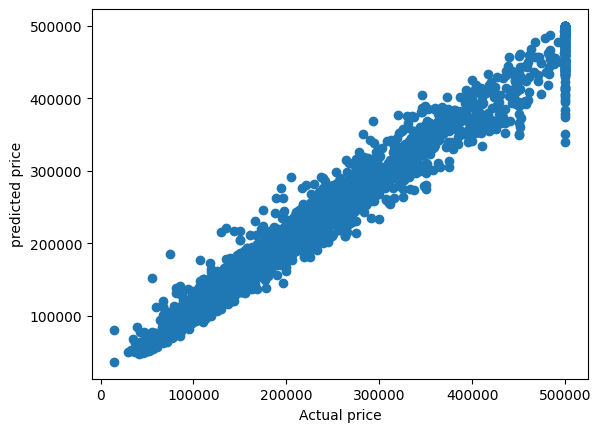

In [57]:
plt.scatter(Y_train,training_data_prediction)
plt.xlabel("Actual price")
plt.ylabel("predicted price")
plt.show()